# Project 1: Student Pass/Fail


## 1. Import libraries and load the data

In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Read the data
df = pd.read_csv('01_student_pass_fail.csv')
df.head()

,study_hours,attendance,assignments_completed,previous_score,pass
0,6.3,84.1,0.0,83.0,1
1,2.6,50.3,4.0,76.0,0
2,8.8,65.3,7.0,92.0,1
3,6.8,99.3,NaN,56.0,1
4,1.1,55.9,2.0,82.0,0


## 2. Understand the dataset

In [8]:
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print('\nData types:')
print(df.dtypes)

Rows: 1020
Columns: 5

Data types:
study_hours              float64
attendance               float64
assignments_completed    float64
previous_score           float64
pass                       int64
dtype: object


In [9]:
df.describe().round(2)

,study_hours,attendance,assignments_completed,previous_score,pass
count,1010.00,1010.00,1010.00,1009.00,1020.0
mean,5.44,74.22,5.09,63.11,0.8
std,2.63,14.79,3.22,19.98,0.4
min,-2.00,50.10,-3.00,30.00,0.0
25%,3.20,60.90,2.00,46.00,1.0
50%,5.50,74.00,5.00,63.00,1.0
75%,7.60,86.80,8.00,80.00,1.0
max,10.00,120.00,10.00,150.00,1.0


The dataset has five numerical columns. The `pass` column is the target: `1` means pass and `0` means fail.

## 3. Check missing values and duplicates

In [10]:
print('Missing values:')
print(df.isna().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values:
study_hours              10
attendance               10
assignments_completed    10
previous_score           11
pass                      0
dtype: int64

Duplicate rows: 20


There are a few missing values in every input column and 20 duplicate rows.

## 4. Find invalid values

In [5]:
invalid_counts = pd.Series({
    'Negative study hours': (df['study_hours'] < 0).sum(),
    'Attendance outside 0-100': ((df['attendance'] < 0) | (df['attendance'] > 100)).sum(),
    'Negative assignments': (df['assignments_completed'] < 0).sum(),
    'Previous score outside 0-100': ((df['previous_score'] < 0) | (df['previous_score'] > 100)).sum()
})
invalid_counts

Negative study hours            5
Attendance outside 0-100        5
Negative assignments            5
Previous score outside 0-100    5
dtype: int64

Each input column contains five impossible values, so they need to be fixed before analysis.

## 5. Explore distributions and outliers

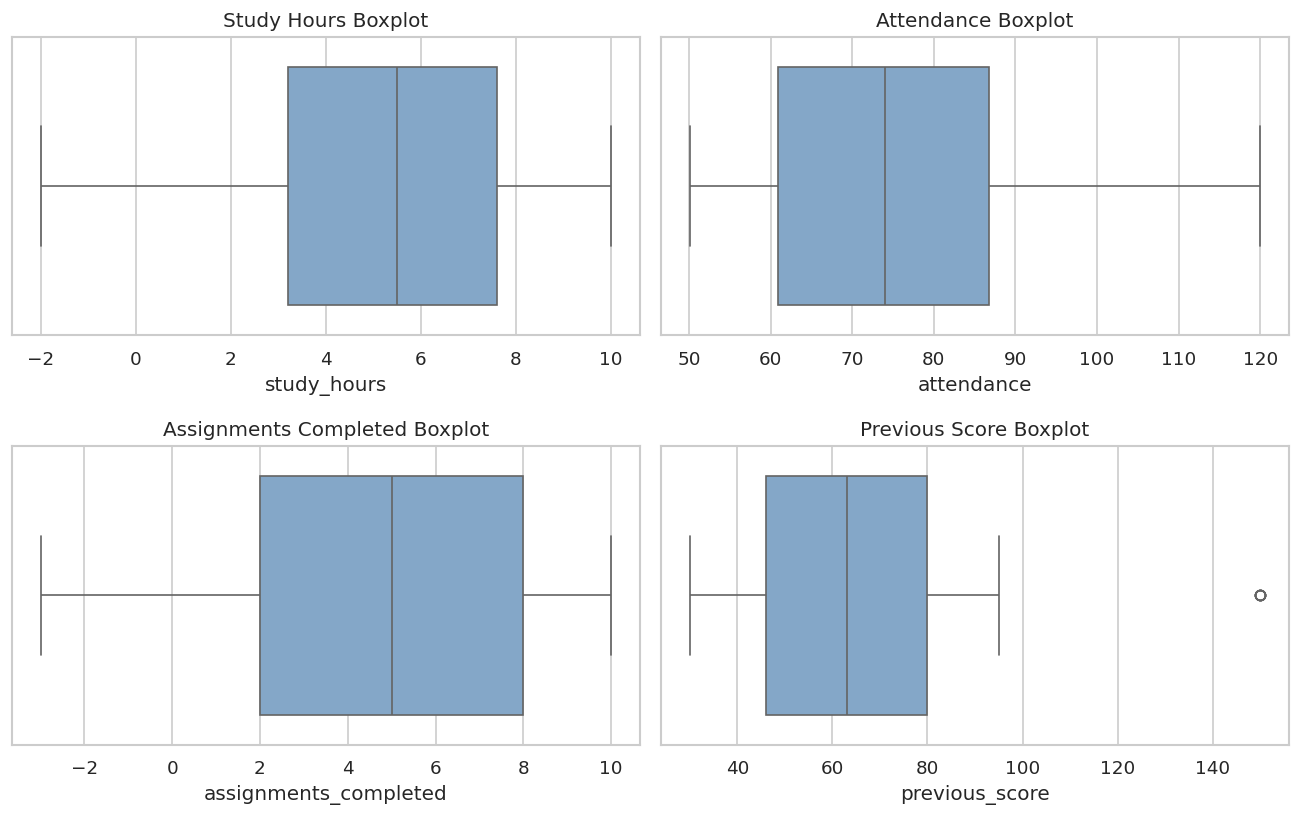

In [6]:
features = ['study_hours', 'attendance', 'assignments_completed', 'previous_score']
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for column, ax in zip(features, axes.flatten()):
    sns.boxplot(x=df[column], ax=ax, color='#79A7D3')
    ax.set_title(f'{column.replace("_", " " ).title()} Boxplot')

plt.tight_layout()
plt.show()

The boxplots make the impossible values easy to spot, especially negative values and values above 100.

## 6. Study hours and pass/fail distribution

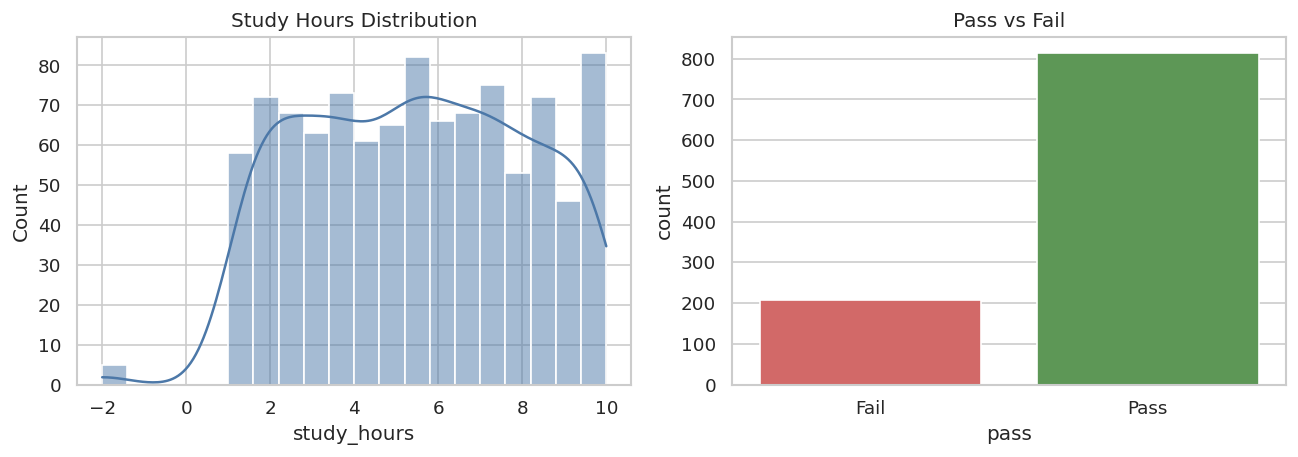

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(df['study_hours'], bins=20, kde=True, ax=axes[0], color='#4C78A8')
axes[0].set_title('Study Hours Distribution')

sns.countplot(data=df, x='pass', hue='pass', legend=False, ax=axes[1], palette=['#E45756', '#54A24B'])
axes[1].set_title('Pass vs Fail')
axes[1].set_xticks([0, 1], ['Fail', 'Pass'])

plt.tight_layout()
plt.show()

In [8]:
pass_counts = df['pass'].value_counts().sort_index()
pass_rate = df['pass'].mean() * 100
print(f'Failed: {pass_counts.get(0, 0)}')
print(f'Passed: {pass_counts.get(1, 0)}')
print(f'Pass rate: {pass_rate:.1f}%')

Failed: 207
Passed: 813
Pass rate: 79.7%


## 7. Compare study habits with pass/fail

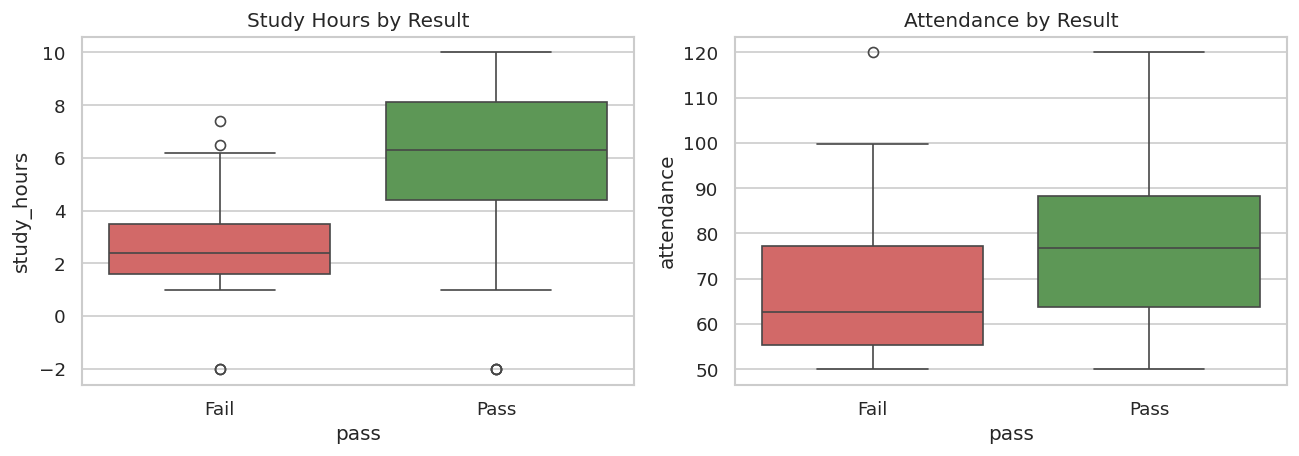

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=df, x='pass', y='study_hours', hue='pass', legend=False, ax=axes[0], palette=['#E45756', '#54A24B'])
axes[0].set_title('Study Hours by Result')
axes[0].set_xticks([0, 1], ['Fail', 'Pass'])

sns.boxplot(data=df, x='pass', y='attendance', hue='pass', legend=False, ax=axes[1], palette=['#E45756', '#54A24B'])
axes[1].set_title('Attendance by Result')
axes[1].set_xticks([0, 1], ['Fail', 'Pass'])

plt.tight_layout()
plt.show()

In [10]:
df.groupby('pass')[['study_hours', 'attendance']].mean().round(2).rename(index={0: 'Fail', 1: 'Pass'})

,study_hours,attendance
pass,,
Fail,2.63,67.07
Pass,6.16,76.05


Students who passed studied more hours and had better attendance on average. This suggests that both habits are associated with passing.

## 8. Correlation heatmap

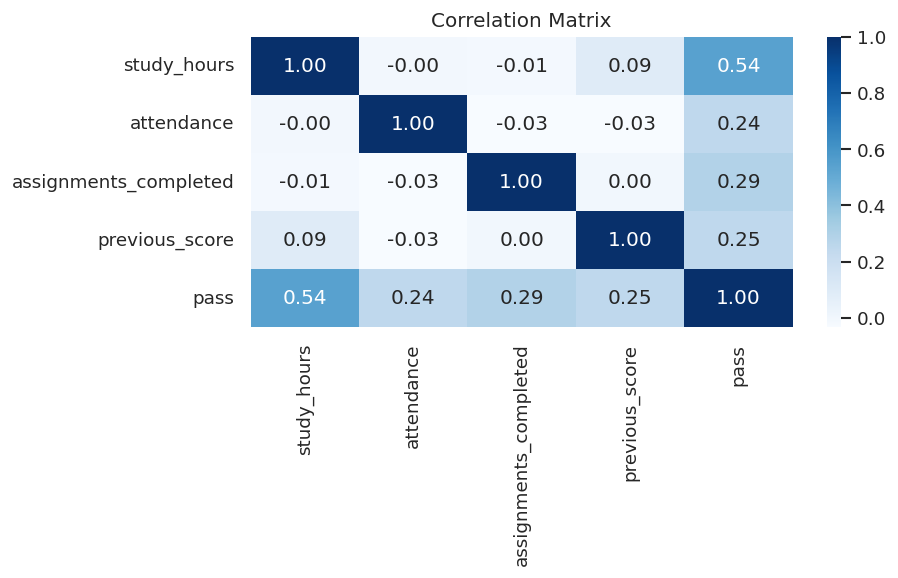

In [11]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Study hours has the strongest positive relationship with passing in this dataset. Attendance, completed assignments, and previous score also move in the same direction.

## 9. Clean the dataset

In [12]:
clean_df = df.drop_duplicates().copy()

# Turn impossible values into missing values.
clean_df.loc[clean_df['study_hours'] < 0, 'study_hours'] = np.nan
clean_df.loc[~clean_df['attendance'].between(0, 100), 'attendance'] = np.nan
clean_df.loc[clean_df['assignments_completed'] < 0, 'assignments_completed'] = np.nan
clean_df.loc[~clean_df['previous_score'].between(0, 100), 'previous_score'] = np.nan

# Median values are simple and less affected by outliers.
input_columns = ['study_hours', 'attendance', 'assignments_completed', 'previous_score']
clean_df[input_columns] = clean_df[input_columns].fillna(clean_df[input_columns].median())

# Assignments are counts, so keep them as whole numbers.
clean_df['assignments_completed'] = clean_df['assignments_completed'].round().astype(int)
clean_df = clean_df.reset_index(drop=True)
clean_df.head()

,study_hours,attendance,assignments_completed,previous_score,pass
0,6.3,84.1,0,83.0,1
1,2.6,50.3,4,76.0,0
2,8.8,65.3,7,92.0,1
3,6.8,99.3,5,56.0,1
4,1.1,55.9,2,82.0,0


In [13]:
print(f'Rows after cleaning: {len(clean_df)}')
print(f'Duplicate rows: {clean_df.duplicated().sum()}')
print(f'Missing values: {clean_df.isna().sum().sum()}')
print(f'Invalid study hours: {(clean_df.study_hours < 0).sum()}')
print(f'Invalid attendance: {(~clean_df.attendance.between(0, 100)).sum()}')
print(f'Invalid assignments: {(clean_df.assignments_completed < 0).sum()}')
print(f'Invalid previous scores: {(~clean_df.previous_score.between(0, 100)).sum()}')

Rows after cleaning: 1000
Duplicate rows: 0
Missing values: 0
Invalid study hours: 0
Invalid attendance: 0
Invalid assignments: 0
Invalid previous scores: 0


After cleaning, the duplicate rows, missing values, and impossible values are gone.

## 10. Create new features

In [14]:
# Combines study time with attendance consistency.
clean_df['study_attendance_score'] = (
    clean_df['study_hours'] * clean_df['attendance'] / 100
).round(2)

# Treat 10 completed assignments as 100 percent.
assignment_percent = clean_df['assignments_completed'] * 10
clean_df['overall_performance'] = (
    (clean_df['attendance'] + clean_df['previous_score'] + assignment_percent) / 3
).round(2)

clean_df.head()

,study_hours,attendance,assignments_completed,previous_score,pass,study_attendance_score,overall_performance
0,6.3,84.1,0,83.0,1,5.30,55.70
1,2.6,50.3,4,76.0,0,1.31,55.43
2,8.8,65.3,7,92.0,1,5.75,75.77
3,6.8,99.3,5,56.0,1,6.75,68.43
4,1.1,55.9,2,82.0,0,0.61,52.63


`study_attendance_score` combines effort and attendance. `overall_performance` gives a simple summary of attendance, previous marks, and completed assignments.

## 11. Separate features and target

In [15]:
X = clean_df.drop(columns='pass')
y = clean_df['pass']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('\nFeature columns:')
print(X.columns.tolist())

X shape: (1000, 6)
y shape: (1000,)

Feature columns:
['study_hours', 'attendance', 'assignments_completed', 'previous_score', 'study_attendance_score', 'overall_performance']


## Final conclusion

The cleaned data shows that passing students generally studied longer, attended more classes, completed more assignments, and had better previous scores. Study hours showed the clearest relationship with the pass result. The dataset is now clean and ready for a basic machine-learning model.